In [1]:
import pandas as pd

df = pd.read_csv('silver_prices_data.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2011-01-24,27.318001,27.459999,26.955000,27.174999,168
1,2011-01-25,26.811001,26.950001,26.565001,26.915001,77
2,2011-01-26,27.132000,27.025000,26.684999,27.025000,49
3,2011-01-27,27.045000,27.684999,27.410000,27.684999,184
4,2011-01-28,27.934000,27.950001,26.504999,26.695000,64


In [2]:
df.info()
df.describe()
df.isnull().sum()

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3768 entries, 0 to 3767
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3768 non-null   object 
 1   Close   3768 non-null   float64
 2   High    3768 non-null   float64
 3   Low     3768 non-null   float64
 4   Open    3768 non-null   float64
 5   Volume  3768 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 176.8+ KB


In [7]:
from sklearn.preprocessing import StandardScaler

df.ffill(inplace=True)

# Better target
df['Target'] = (df['Close'] > df['Open']).astype(int)

# Feature Engineering (IMPORTANT)
df['Range'] = df['High'] - df['Low']
df['Change'] = df['Close'] - df['Open']

# Features
X = df[['Open', 'High', 'Low', 'Volume', 'Range', 'Change']]
y = df['Target']

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Tuned model
model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Trained")

Model Trained


Accuracy: 0.8594164456233422

Confusion Matrix:
 [[319 105]
 [  1 329]]

Report:
               precision    recall  f1-score   support

           0       1.00      0.75      0.86       424
           1       0.76      1.00      0.86       330

    accuracy                           0.86       754
   macro avg       0.88      0.87      0.86       754
weighted avg       0.89      0.86      0.86       754



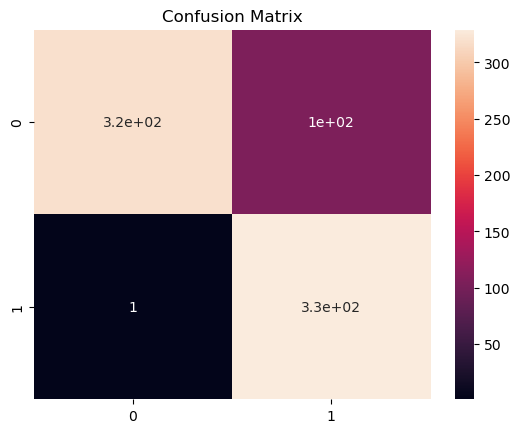

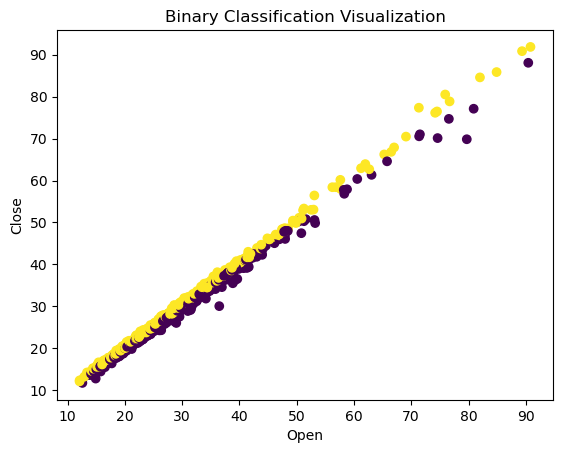

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.title("Confusion Matrix")
plt.show()

# Scatter Plot (Class Visualization)
plt.scatter(df['Open'], df['Close'], c=df['Target'])
plt.xlabel("Open")
plt.ylabel("Close")
plt.title("Binary Classification Visualization")
plt.show()